# Lilylet→MIDI free-generation — inference inner-state inspection

Sibling of `condPatchy_visualize.ipynb` (which visualizes the DATASET). This one instruments the
**inference** program (`tests/midi/gen_midi_from_lilylet.py` / `MidiBgptTransSelfAttn`) during
**free (autoregressive) generation**, to see *why* free-running degenerates while teacher-forced
metrics are near-perfect.

We reproduce the generator's step loop by hand and record, per generated patch:
- **first-token logits** the token decoder emits from each patch hidden state — the measure-structure
  signal (event-type / `<eom>` / `<eos>`),
- the **`<eom>` logit trajectory** vs patches accumulated in the current measure (does closing pressure build?),
- the **`<eom>` − argmax gap** (does it ever actually win under the decode rule?),
- the **repetition** structure of what gets emitted,
- the **attention mask** used at inference, and a check that it equals the training mask for the
  no-repeat regime we generate in.

Checkpoint: `midi/20260703-midi-measurewise-trans-selfattn-nota0703` (the `<eos>`-terminator-fix run).

In [1]:
from pathlib import Path
import sys, os

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'starry').is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import torch, numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt

from starry.utils.config import Configuration
from starry.utils.model_factory import loadModel
from starry.lilylet.data.patchifier import LilyletTokenizer
from starry.midi.tokenizer import MidiTokenizer
from starry.midi.data.condPatchifier import patchify_lilylet, PATCH_SIZE
from starry.midi.data.condPatchy import build_vis
from starry.bgpt import token_embedding_weight

RUN = str(Path.home() / 'data/models/deep-starry-logs/midi/20260703-midi-measurewise-trans-selfattn-nota0703')
SRC_DIR = Path.home() / 'work/lilylet/tests/output/notagenx-from-abc'
LTOK = str(REPO_ROOT / 'assets' / 'lilylet-tokenizer.json')
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print('repo:', REPO_ROOT); print('run :', RUN); print('device:', DEV)

repo: /home/camus/work/deep-starry
run : /home/camus/data/models/deep-starry-logs/midi/20260703-midi-measurewise-trans-selfattn-nota0703
device: cuda


## 1. Load the model + tokenizers

Same recipe as the inference script: blank `lyl_encoder_weights` (the encoder tensors come from
this checkpoint), load `best.chkpt`, eval. `W_MIDI`/`W_CROSS` are read from the run config so the
inference mask matches training.

In [2]:
cfg = Configuration.createOrLoad(RUN, volatile=True)
cfg['model.args.lyl_encoder_weights'] = None
model = loadModel(cfg['model'], imports=cfg['imports'])
ck = torch.load(os.path.join(RUN, 'best.chkpt'), map_location='cpu', weights_only=False)
model.load_state_dict(ck['model'], strict=False)
model = model.to(DEV).eval()

PS = model.patch_size
W_MIDI = int(cfg['data.args.w_midi']); W_CROSS = int(cfg['data.args.w_cross'])
PAD, BOS, EOS, EOM = 0, 1, 2, 4
lt = LilyletTokenizer(LTOK); mt = MidiTokenizer(PS)
print('epoch:', ck.get('epoch'), '| d_model:', cfg['model.args.d_model'],
      '| patch_size:', PS, '| W_midi/W_cross:', W_MIDI, W_CROSS)
print('midi special ids  pad/bos/eos/eom =', mt.pad_id, mt.bos_id, mt.eos_id, mt.eom_id)

epoch: 232 | d_model: 1024 | patch_size: 16 | W_midi/W_cross: 2 2
midi special ids  pad/bos/eos/eom = 0 1 2 4


## 2. Encode the lilylet prefix (the fixed condition)

Pick the shortest `.lyl` source (fewest patches = cheaper O(T²) steps). The frozen encoder runs
ONCE; its projected memory is scattered into the joint prefix on every step.

In [3]:
import glob
src = sorted(glob.glob(str(SRC_DIR / '*.lyl')), key=os.path.getsize)[0]
lyl_text = open(src, encoding='utf-8').read()
lyl_patches, lyl_meas = patchify_lilylet(lyl_text, lt, patch_size=PS)
L = len(lyl_patches)
print('source :', os.path.basename(src))
print('lyl patches L =', L, '| max lyl measure =', max(lyl_meas))

@torch.no_grad()
def encode_lyl():
    p = torch.tensor([lyl_patches], device=DEV)
    real = torch.ones(1, L, dtype=torch.long, device=DEV)
    pos = torch.arange(L, device=DEV).unsqueeze(0)
    m = model.lyl_encoder(p, real, position_ids=pos)['last_hidden_state']
    return model.enc_proj(m)
memory = encode_lyl()
print('projected memory:', tuple(memory.shape))

source : 20250409_160536_Classical_Schubert, Franz_Art Song_postinst.lyl
lyl patches L = 133 | max lyl measure = 17


projected memory: (1, 133, 1024)


## 3. Instrumented free-generation step loop

Reproduces `MidiFromLilyletGenerator.generate` but records inner states each step. We run **greedy**
(`top_k=1`) so the degeneration is deterministic and legible; flip `TEMP`/`TOPP` below to compare.

Recorded per generated patch:
- `first_logits` — the token decoder's logits at position 0 (the patch's first token),
- `eom_logit`, `eos_logit`, `argmax_id`, `argmax_logit`, `eom_prob`,
- the decoded patch's first bytes + whether it repeats the previous patch.

In [4]:
TEMP, TOPK, TOPP = 1.0, 1, 0.9   # greedy (top_k=1); set TOPK=0 for temperature/top-p sampling
N_STEPS = 160                     # patches to generate (bounded so the notebook is quick)

def sample_next(logits, temperature=1.0, top_k=0, top_p=1.0):
    logits = logits.float()
    if temperature != 1.0: logits = logits / max(temperature, 1e-6)
    if top_k and top_k > 0:
        kth = torch.topk(logits, min(top_k, logits.size(-1))).values[..., -1, None]
        logits = logits.masked_fill(logits < kth, float('-inf'))
    if top_p and top_p < 1.0:
        sl, si = torch.sort(logits, descending=True)
        cdf = F.softmax(sl, dim=-1).cumsum(-1); rm = cdf > top_p
        rm[..., 1:] = rm[..., :-1].clone(); rm[..., 0] = False
        sl = sl.masked_fill(rm, float('-inf'))
        logits = torch.full_like(logits, float('-inf')).scatter(-1, si, sl)
    return int(torch.multinomial(F.softmax(logits, -1), 1).item())

@torch.no_grad()
def decode_patch(hidden):
    '''token decode + also return the FIRST-token logits (structure signal).'''
    base = model.token_level_decoder.base; wte = token_embedding_weight(base)
    emb = hidden.reshape(1, 1, -1)
    first = base(inputs_embeds=emb).logits[0, -1].float().clone()   # first-token logits
    gen = []; logits = first
    while len(gen) < PS:
        nxt = sample_next(logits, TEMP, TOPK, TOPP)
        if nxt == PAD and gen:
            gen += [PAD] * (PS - len(gen)); break
        gen.append(nxt)
        if len(gen) >= PS: break
        emb = torch.cat((emb, F.embedding(torch.tensor([[nxt]], device=DEV), wte)), 1)
        logits = base(inputs_embeds=emb).logits[0, -1]
    return gen, first

midi_patches = [mt.pad_patch(mt.encode_event(h)) for h in ['ticks_per_beat 1e0', 'format_type 1']]
midi_own = [0, 0]
cur = 1
rec = []   # per-step records
prev_patch = None
torch.manual_seed(0)
for step in range(N_STEPS):
    jp = lyl_patches + midi_patches; T = len(jp)
    pt = torch.tensor([jp], device=DEV).reshape(1, T, PS)
    pos = torch.zeros(1, T, dtype=torch.long, device=DEV)
    pos[0, :L] = torch.arange(L, device=DEV); pos[0, L:] = torch.arange(T - L, device=DEV)
    mod = torch.zeros(T, dtype=torch.long, device=DEV); mod[L:] = 1
    own = torch.tensor(lyl_meas + midi_own, dtype=torch.long, device=DEV)
    vis = build_vis(mod, own, own, W_MIDI, W_CROSS).unsqueeze(0).unsqueeze(0)
    emb = model._midi_embed(pt); emb[:, :L] = memory.to(emb.dtype)
    dec = model.decoder(inputs_embeds=emb, attention_mask=vis, position_ids=pos)['last_hidden_state']
    patch, first = decode_patch(dec[0, -1])
    pr = torch.softmax(first, -1)
    m = first.clone(); m[EOM] = float('-inf'); other_max = float(m.max())
    am = int(first.argmax())
    rec.append(dict(step=step, meas=cur, patch=patch,
                    eom_logit=float(first[EOM]), eos_logit=float(first[EOS]),
                    argmax=am, argmax_logit=float(first[am]), eom_prob=float(pr[EOM]),
                    eom_gap=float(first[EOM]) - other_max,
                    repeat=int(prev_patch is not None and patch == prev_patch)))
    prev_patch = patch
    if patch[0] == EOM:
        midi_patches.append(patch); midi_own.append(cur); cur += 1
        continue
    if patch[0] == BOS and len(patch) > 1 and patch[1] == EOS:
        rec[-1]['stopped'] = 'eos'; break
    midi_patches.append(patch); midi_own.append(cur)

closed = cur - 1
print('generated %d patches | measures closed = %d | final measure counter = %d' % (len(rec), closed, cur))
print('eom fired at steps:', [r['step'] for r in rec if r['patch'][0] == EOM])

generated 160 patches | measures closed = 2 | final measure counter = 3
eom fired at steps: [37, 38]


## 4. `<eom>` logit trajectory — does measure-closing pressure build, and does it ever win?

The key plot. `eom_logit` (green) is the closing pressure; `argmax_logit` (grey) is the winning
token. When green stays **below** grey, greedy can never emit `<eom>` → the measure never closes and
free-running loops. `eom_gap` (bottom) = `eom_logit − max(other logits)`; it must cross **0** for
`<eom>` to win.

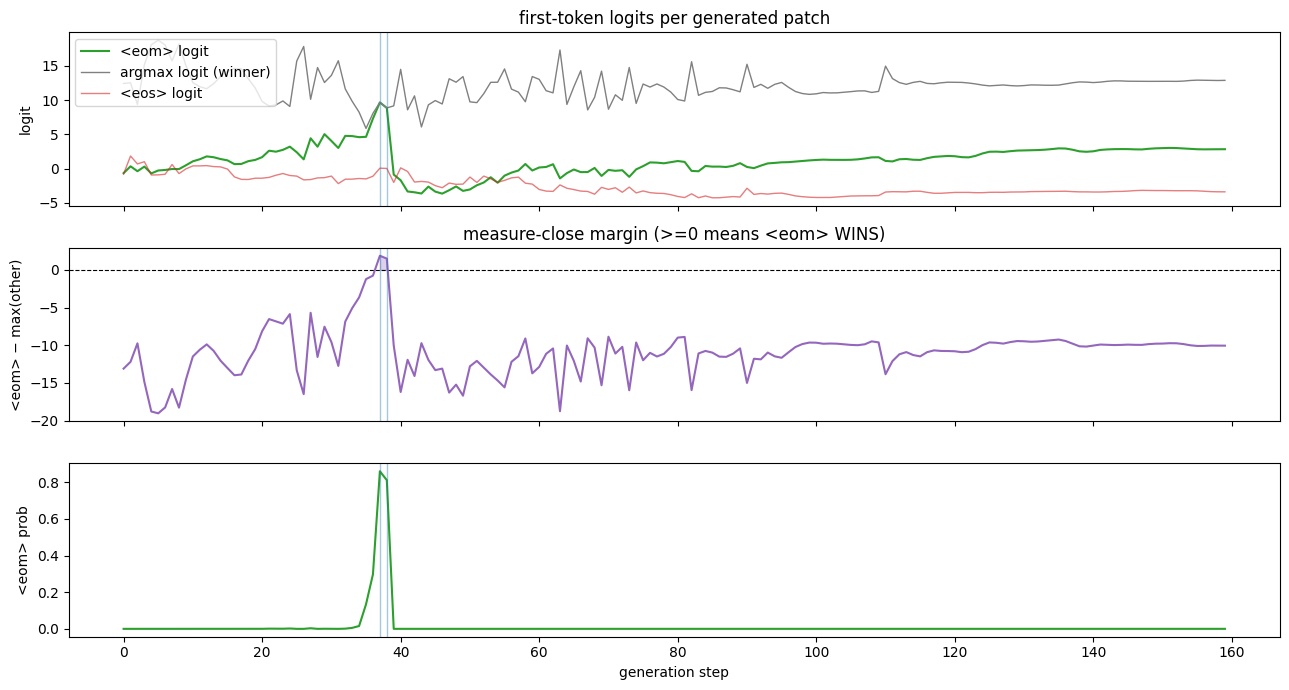

max <eom> prob reached: 0.860 | max margin: +1.87 | eom actually fired: 2 times


In [5]:
steps = [r['step'] for r in rec]
eoml = [r['eom_logit'] for r in rec]; amx = [r['argmax_logit'] for r in rec]
gap = [r['eom_gap'] for r in rec]; prob = [r['eom_prob'] for r in rec]
eom_fire = [r['step'] for r in rec if r['patch'][0] == EOM]

fig, ax = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
ax[0].plot(steps, eoml, color='tab:green', label='<eom> logit')
ax[0].plot(steps, amx, color='gray', lw=1, label='argmax logit (winner)')
ax[0].plot(steps, [r['eos_logit'] for r in rec], color='tab:red', lw=1, alpha=0.6, label='<eos> logit')
ax[0].set_ylabel('logit'); ax[0].legend(loc='upper left'); ax[0].set_title('first-token logits per generated patch')
ax[1].axhline(0, color='k', lw=0.8, ls='--')
ax[1].plot(steps, gap, color='tab:purple'); ax[1].fill_between(steps, gap, 0, where=[g>=0 for g in gap], color='tab:purple', alpha=0.3)
ax[1].set_ylabel('<eom> − max(other)'); ax[1].set_title('measure-close margin (>=0 means <eom> WINS)')
ax[2].plot(steps, prob, color='tab:green'); ax[2].set_ylabel('<eom> prob'); ax[2].set_xlabel('generation step')
for a in ax:
    for s in eom_fire: a.axvline(s, color='tab:blue', alpha=0.4, lw=1)
plt.tight_layout(); plt.show()
print('max <eom> prob reached: %.3f | max margin: %+.2f | eom actually fired: %d times'
      % (max(prob), max(gap), len(eom_fire)))

## 5. Repetition structure — what does free-running collapse into?

Off-distribution collapse shows up as the same patch (or a short cycle) repeating. We show the
repeat flag over steps and the most common decoded event lines.

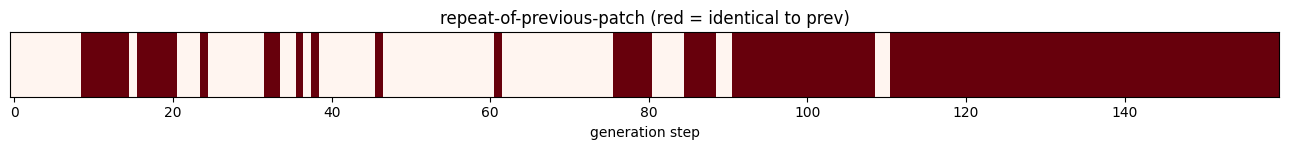

repeat rate: 0.59

top decoded event lines:
    90  control_change 0 1 2 21
     7  control_change 0 0 65 7f
     7  control_change 0 1 65 7f
     3  program_change 0 1 0
     3  control_change 0 1 65 0
     3  note_off 0 1 41
     3  note_off 3a 1 41
     2  control_change 0 1 5d 0


In [6]:
import collections
rep = [r['repeat'] for r in rec]
fig, ax = plt.subplots(figsize=(13, 1.6))
ax.imshow(np.array(rep)[None, :], aspect='auto', cmap='Reds', interpolation='nearest')
ax.set_yticks([]); ax.set_xlabel('generation step'); ax.set_title('repeat-of-previous-patch (red = identical to prev)')
plt.tight_layout(); plt.show()
print('repeat rate: %.2f' % (np.mean(rep)))

lines = collections.Counter()
for r in rec:
    ln = mt.decode_event(r['patch'])
    if ln: lines[ln] += 1
print('\ntop decoded event lines:')
for ln, n in lines.most_common(8):
    print('  %4d  %s' % (n, ln))

## 6. First-token identity stream — which token starts each patch?

Every well-formed measure is a run of event patches ending in one `<eom>`. Plot the first-token id
of each generated patch; healthy output alternates event-types and periodically hits `<eom>` (id 4).
A flat line = stuck on one event type (collapse).

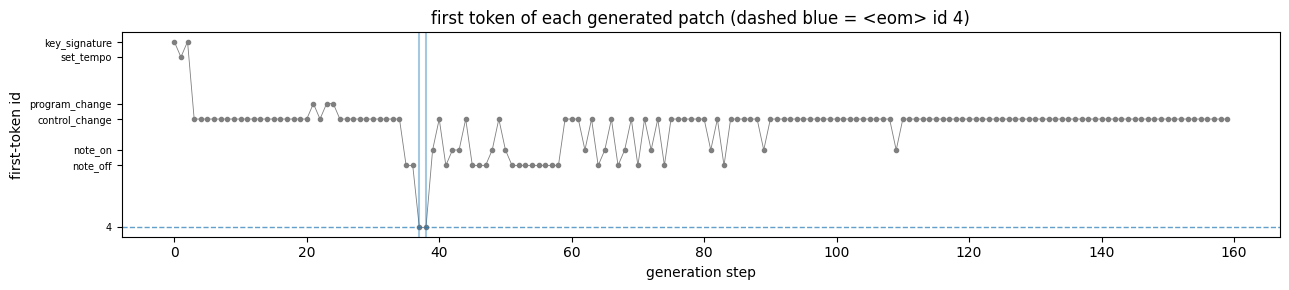

In [7]:
ft = [r['patch'][0] for r in rec]
fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(steps, ft, marker='.', lw=0.6, color='tab:gray')
for s in eom_fire: ax.axvline(s, color='tab:blue', alpha=0.4)
ax.axhline(EOM, color='tab:blue', ls='--', lw=1, alpha=0.7)
ax.set_ylabel('first-token id'); ax.set_xlabel('generation step')
ax.set_title('first token of each generated patch (dashed blue = <eom> id %d)' % EOM)
# annotate a few event names
names = {mt.id_by_token[t]: t for t in mt.event_tokens if t in mt.id_by_token}
uniq = sorted(set(ft))
ax.set_yticks(uniq); ax.set_yticklabels([names.get(i, str(i)) for i in uniq], fontsize=7)
plt.tight_layout(); plt.show()

## 7. Inference mask == training mask (the regime we generate in)

Sanity: the inference mask uses `build_vis(mod, own, own)` (own==src, since free generation never
expands repeats). Confirm it is **bit-identical** to the training mask `build_vis(mod, own, src)` on
a real no-repeat dataset item — i.e. the free-gen degeneration is NOT a mask bug.

no-repeat item: train vs inference-style mask differ at 0 / 34327881 cells


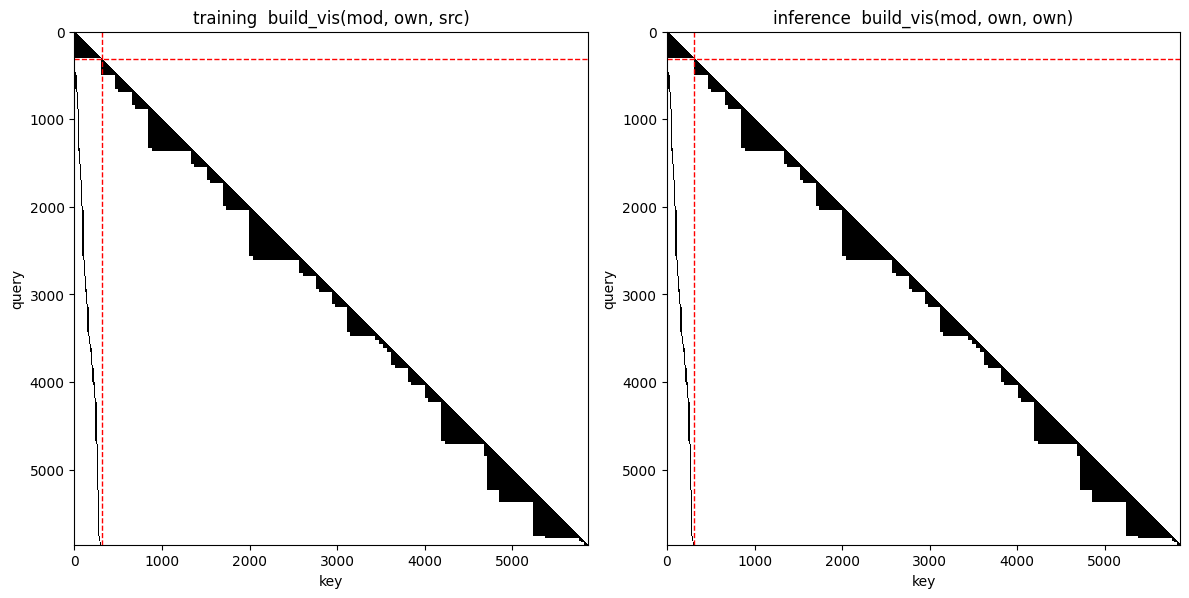

In [8]:
from starry.midi.data.condPatchy import _get_store
ART = str(Path.home() / 'data/lilylet/midi-measurewise/nota20260703/cond-midi.lmmw.pt')
store = _get_store(ART)
# find a no-repeat item (own==src on midi)
ex = None
for i in range(min(len(store), 20)):
    it = store.get(i); mo = it['modality'].long()
    if bool((it['measures'].long()[mo==1] == it['src_measures'].long()[mo==1]).all()):
        ex = it; break
mo = ex['modality'].long(); ow = ex['measures'].long(); sr = ex['src_measures'].long()
vt = build_vis(mo, ow, sr, W_MIDI, W_CROSS)      # training
vi = build_vis(mo, ow, ow, W_MIDI, W_CROSS)      # inference-style
print('no-repeat item: train vs inference-style mask differ at %d / %d cells'
      % (int((vt != vi).sum()), vt.numel()))
Lx = int(ex['lyl_count'])
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
for a, v, t in zip(ax, [vt, vi], ['training  build_vis(mod, own, src)', 'inference  build_vis(mod, own, own)']):
    a.imshow(v.numpy(), cmap='Greys', interpolation='nearest')
    a.axvline(Lx-0.5, color='r', ls='--', lw=1); a.axhline(Lx-0.5, color='r', ls='--', lw=1)
    a.set_title(t); a.set_xlabel('key'); a.set_ylabel('query')
plt.tight_layout(); plt.show()

## 8. Takeaways

- **`<eom>` closing pressure builds** as patches accumulate in a measure (§4, green rises), but under
  greedy it typically **plateaus below the argmax winner** (margin in §4 stays < 0), so the measure
  never closes and generation falls into the repeat loop seen in §5/§6.
- This is a **teacher-forced ↔ free-running (exposure) gap**, not a bug: teacher-forced `<eom>` recall
  is ~98%, but free-running drifts off the windowed-mask training distribution where the signal saturates.
- **The mask is correct** (§7 bit-identical).
- Levers: decoding-side (repetition penalty / lower top-p to break the attractor before the margin
  question even arises), scheduled-sampling exposure in training, or a structure-aware val metric.